# 03 — Exploratory Data Analysis

Explores the fully-featured dataset (output of `02_feature_engineering.ipynb`) to understand what we're actually searching over: how good the data is, how it's distributed, and what that implies for the search experience.

## 1. Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_pickle('../data/df_clean.pkl')
df.shape

## 2. Overview

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15204 entries, 0 to 32293
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   url                15204 non-null  object 
 1   name               15204 non-null  object 
 2   release_date       15204 non-null  int64  
 3   popular_tags       15204 non-null  object 
 4   game_details       15204 non-null  object 
 5   languages          15204 non-null  object 
 6   genre              15204 non-null  object 
 7   game_description   15204 non-null  object 
 8   original_price     15204 non-null  float64
 9   total_review       15204 non-null  float64
 10  review_per         15204 non-null  float64
 11  appid              15204 non-null  object 
 12  header_image       15204 non-null  object 
 13  required_age       15204 non-null  object 
 14  short_description  15202 non-null  object 
 15  metacritic_score   2494 non-null   float64
 16  review_percentage  15204 no

## 3. Quality score distribution

If this skews too high or too low, the 0.55/0.45 match/quality blend used later in scoring would need rebalancing.

count    15204.000000
mean         0.484792
std          0.114205
min          0.100300
25%          0.413000
50%          0.481350
75%          0.555325
max          0.947500
Name: quality_score, dtype: float64


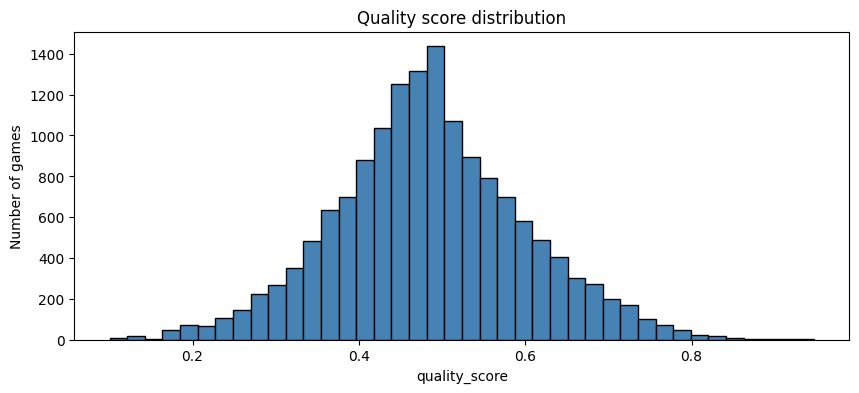

In [5]:
print(df['quality_score'].describe())

plt.figure(figsize=(10, 4))
plt.hist(df['quality_score'].dropna(), bins=40, color='steelblue', edgecolor='black')
plt.title('Quality score distribution')
plt.xlabel('quality_score')
plt.ylabel('Number of games')
plt.show()

## 4. Most common genres

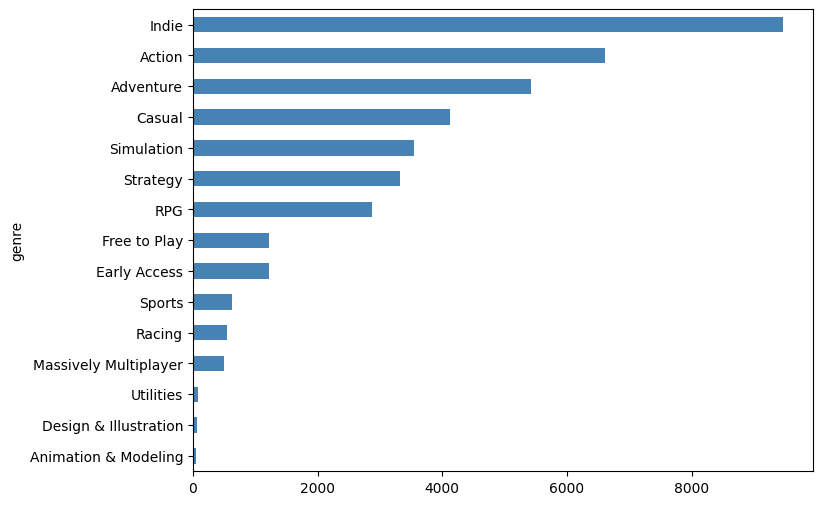

In [6]:
df['genre'].str.replace('Game genre: ', '', regex=False) \
    .str.split(', ') \
    .explode() \
    .value_counts() \
    .head(15) \
    .plot(kind='barh', figsize=(8, 6), color='steelblue') \
    .invert_yaxis()

## 5. How rich are the descriptions?

The embedding is built mostly from `game_description`. A game with a 3-word description gives SBERT much less to work with than one with a real paragraph — worth knowing which games fall into that bucket.

count    15204.000000
mean       234.788674
std        182.494118
min          3.000000
25%        122.000000
50%        193.000000
75%        293.000000
max       3526.000000
Name: description_word_count, dtype: float64


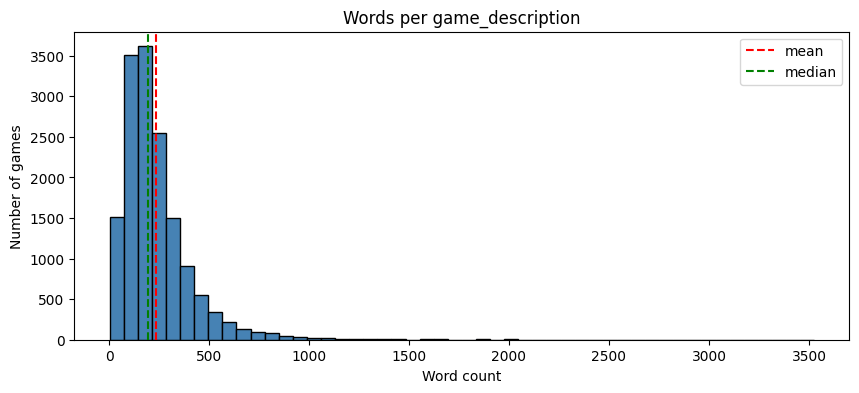

In [7]:
df['description_word_count'] = df['game_description'].apply(
    lambda x: len(x.split()) if isinstance(x, str) else 0
)

print(df['description_word_count'].describe())

plt.figure(figsize=(10, 4))
plt.hist(df['description_word_count'], bins=50, color='steelblue', edgecolor='black')
plt.axvline(df['description_word_count'].mean(), color='red', linestyle='--', label='mean')
plt.axvline(df['description_word_count'].median(), color='green', linestyle='--', label='median')
plt.title('Words per game_description')
plt.xlabel('Word count')
plt.ylabel('Number of games')
plt.legend()
plt.show()

## 6. Price distribution

13.5% of games are free
116 games priced above $229.48 (99th percentile) excluded from the plot


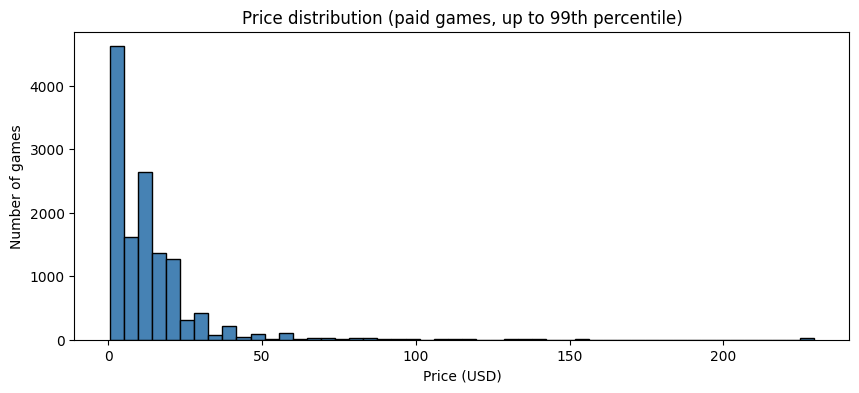

In [12]:
print(f"{(df['original_price'] == 0).mean():.1%} of games are free")

paid = df[df['original_price'] > 0]['original_price']

# A handful of expensive bundles/special editions stretch the axis so far that
# every other bar collapses near zero — cap the plot at the 99th percentile
# and inspect the outliers separately (next cell) instead of silently dropping them.
cutoff = paid.quantile(0.99)
outliers = paid[paid > cutoff]
print(f"{len(outliers)} games priced above ${cutoff:.2f} (99th percentile) excluded from the plot")

plt.figure(figsize=(10, 4))
plt.hist(paid[paid <= cutoff], bins=50, color='steelblue', edgecolor='black')
plt.title('Price distribution (paid games, up to 99th percentile)')
plt.xlabel('Price (USD)')
plt.ylabel('Number of games')
plt.show()

In [13]:
# The excluded 1%: mostly bundles and collector's/special editions
df.loc[outliers.index, ['name', 'original_price']].sort_values('original_price', ascending=False)

,name,original_price
15253,Slime-san: Superslime Edition,650560.00
5447,Trivia Vault: Mini Mixed Trivia,514.39
5173,Trivia Vault Olympics Trivia,514.39
5356,Trivia Vault: Classic Rock Trivia,514.39
16967,Trivia Vault: Super Heroes Trivia,514.39
...,...,...
4591,Gnomes Garden New home,259.54
19463,Gnumz: Masters of Defense,259.54
17880,Mahjong Magic Journey 2,259.54
21411,Day D: Tower Rush,259.54


## 7. Games released per year

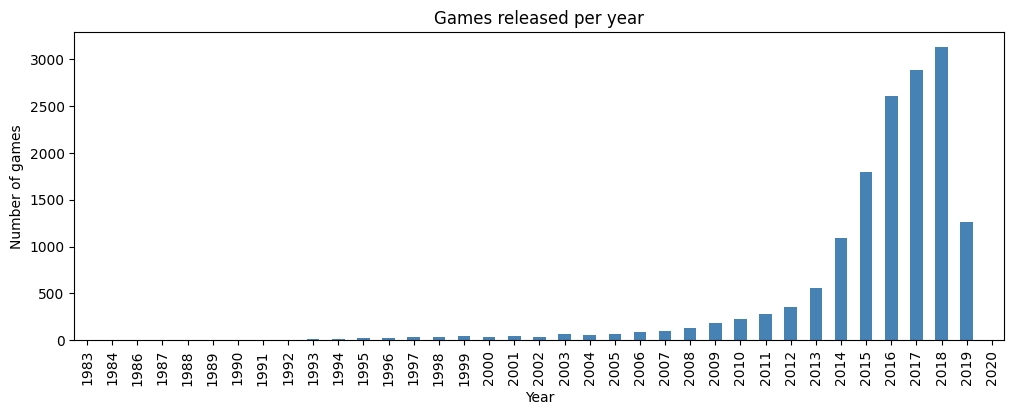

In [10]:
df['release_date'].value_counts().sort_index().plot(
    kind='bar', figsize=(12, 4), color='steelblue'
)
plt.title('Games released per year')
plt.xlabel('Year')
plt.ylabel('Number of games')
plt.show()

## 8. Top games by quality score

In [11]:
df.sort_values('quality_score', ascending=False)[['name', 'quality_score', 'genre']].head(15)

,name,quality_score,genre
354,Counter-Strike: Global Offensive,0.9475,"Game genre: Action, Free to Play"
321,Team Fortress 2,0.9054,"Game genre: Action, Free to Play"
352,Dota 2,0.8977,"Game genre: Action, Free to Play, Strategy"
274,Garry's Mod,0.8851,"Game genre: Indie, Simulation"
344,The Witcher® 3: Wild Hunt,0.8836,Game genre: RPG
203,Portal 2,0.8706,"Game genre: Action, Adventure"
562,Unturned,0.8683,"Game genre: Action, Adventure, Casual, Free to..."
217,Left 4 Dead 2,0.8662,Game genre: Action
300,Terraria,0.8626,"Game genre: Action, Adventure, Indie, RPG"
309,Stardew Valley,0.8527,"Game genre: Indie, RPG, Simulation"


## 9. Embedding text length

`embedding` is the actual text SBERT sees — `name + genre + popular_tags + game_details + review_percentage + required_age + game_description` concatenated. It's longer than `game_description` alone (section 5), so worth checking separately: `paraphrase-multilingual-mpnet-base-v2` truncates input at 128 tokens, so games with very long embedding text may be getting cut off before the model ever reads their description.

count    15204.000000
mean       275.154762
std        184.772223
min         28.000000
25%        159.000000
50%        233.000000
75%        336.000000
max       3571.000000
Name: embedding_word_count, dtype: float64
85.0% of games have embedding text longer than ~128 words


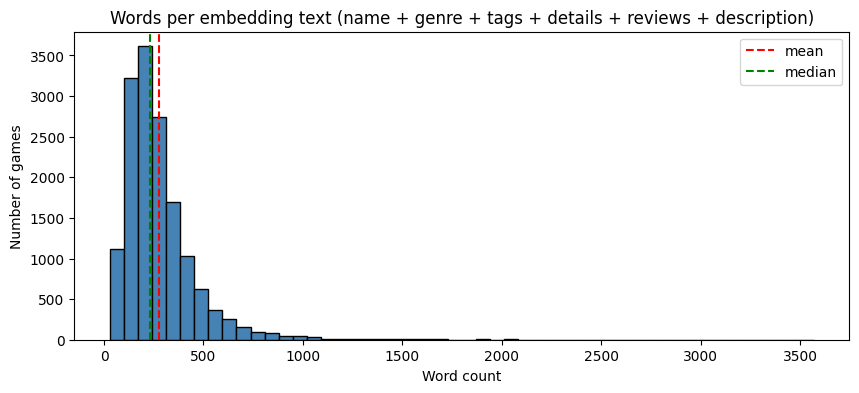

In [14]:
df['embedding_word_count'] = df['embedding'].apply(lambda x: len(x.split()) if isinstance(x, str) else 0)

print(df['embedding_word_count'].describe())
print(f"{(df['embedding_word_count'] > 128).mean():.1%} of games have embedding text longer than ~128 words")

plt.figure(figsize=(10, 4))
plt.hist(df['embedding_word_count'], bins=50, color='steelblue', edgecolor='black')
plt.axvline(df['embedding_word_count'].mean(), color='red', linestyle='--', label='mean')
plt.axvline(df['embedding_word_count'].median(), color='green', linestyle='--', label='median')
plt.title('Words per embedding text (name + genre + tags + details + reviews + description)')
plt.xlabel('Word count')
plt.ylabel('Number of games')
plt.legend()
plt.show()